## Påverkan av klimat och läckage från närliggande tunnel
*Del 2: Tillägg av läckagemodell*

Denna notebook utgår från modellen där enbart naturlig grundvattenbildning tas hänsyn till och lägger till läckage som stress.

Steg:
1. Importera bibliotek
2. Ladda in kalibrerad klimatmodell
3. Ladda och bearbeta läckagedata
4. Lägg till läckagemodell och kalibrera
5. Visa resultat och spara modell

### 0. Importera bibliotek

In [2]:
import os
import pandas as pd
import pastas as ps
from sklearn.metrics import r2_score

ps.set_log_level("ERROR")

### 1. Ladda in kalibrerad klimatmodell

In [3]:
WELL_NAME = "17U"
model_path_in = "../data/obj_17U_m1.pas"

ml_2 = getattr(ps, "io").load(model_path_in)
ml_2.name = f"{WELL_NAME}_m2"

tmin = "2017-07-01"
tmax = "2021-04-01"

print(f"Inläst modell: {ml_2.name}")
print(f"Stressmodeller före tillägg: {list(ml_2.stressmodels.keys())}")

Inläst modell: 17U_m2
Stressmodeller före tillägg: ['recharge']


### 2. Ladda och bearbeta läckagedata

In [8]:
data_mapp = "../data"
idx = pd.date_range("2015-01-01", "2021-04-01", freq="D")

df_leak = pd.read_csv(
    os.path.join(data_mapp, "leak_tunnel_gbg.csv"),
    sep=";",
    encoding="cp1252"
)

# bearbetning av läckagedata (interpolering, tidsindexering, etc.)
def build_leakage(series, date_col):
    return (
        df_leak[[date_col, series]]
        .dropna()
        .assign(**{date_col: lambda d: pd.to_datetime(d[date_col], errors="coerce")})
        .dropna(subset=[date_col])
        .set_index(date_col)[series]
        .sort_index()
        .reindex(idx)
        .interpolate("linear")
        .fillna(0.0)
        .asfreq("D")
        .rename(series)
    )

L_stresses = [
    build_leakage(f"E04-0{i}", f"date{i}")
    for i in range(2, 9)
]

distances = (
    pd.read_csv(
        os.path.join(data_mapp, "leak_dist_tunnel_gbg.csv"),
        sep=";",
        index_col="distance"
    )
    .sort_index()
    .loc["E04-02":"E04-08", WELL_NAME]
    .astype(int)
    .tolist()
)

print(f"Antal läckageserier: {len(L_stresses)}")
print(f"Avstånd (m): {distances}")

Antal läckageserier: 7
Avstånd (m): [248, 249, 270, 323, 389, 476, 603]


### 3. Lägg till läckagemodell och kalibrera

<Axes: ylabel='Head'>

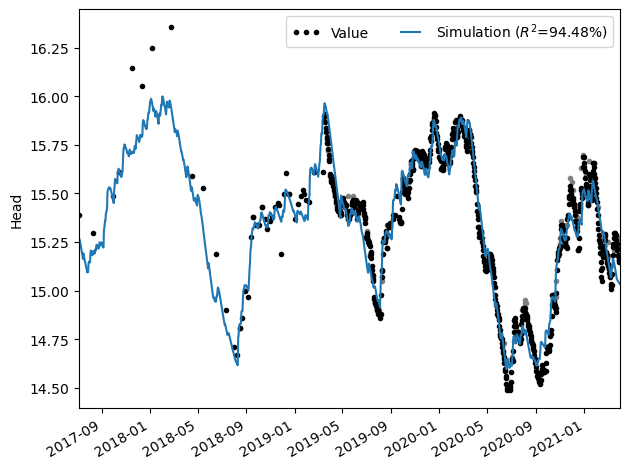

In [9]:

ml_2.add_stressmodel(
    ps.WellModel(
        stress=L_stresses,
        rfunc=ps.HantushWellModel(),
        name="leakage",
        distances=distances,
    )
)

ml_2.solve(
    report=False,
    solver=ps.LmfitSolve(),
    tmin=tmin,
    tmax=tmax,
)

ml_2.plot()

### 4. Visa resultat

Aktiva stressmodeller: ['recharge', 'leakage']


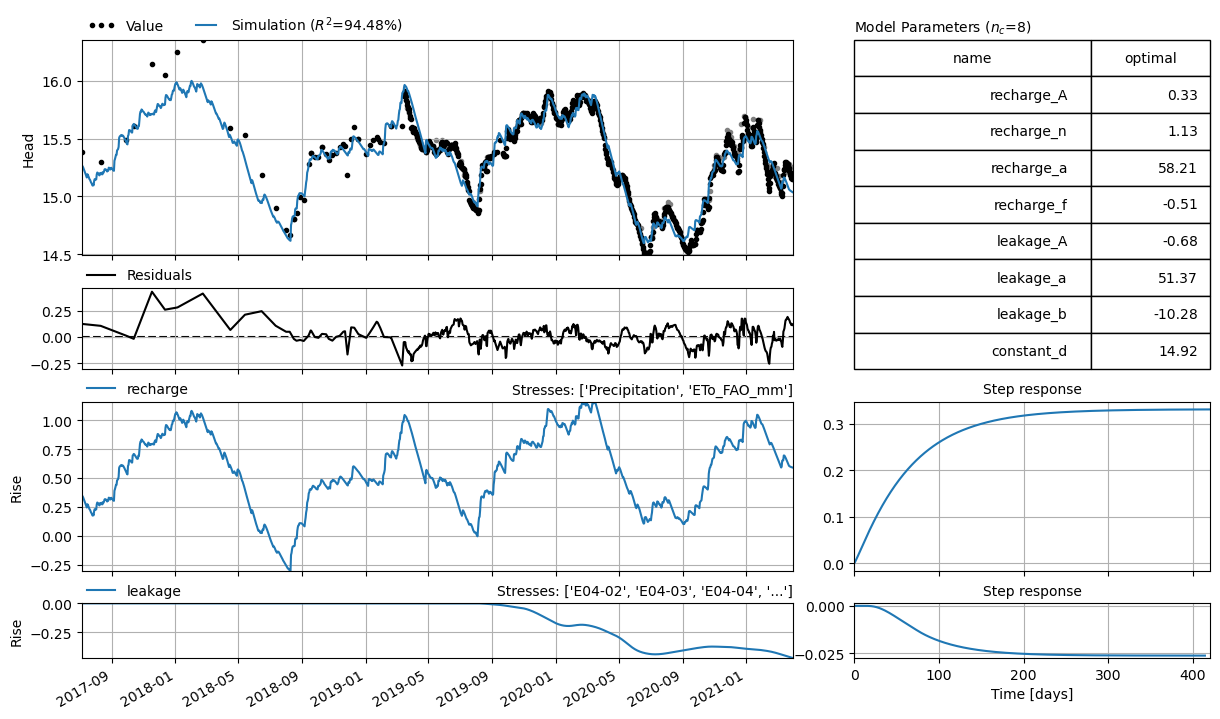

In [11]:
ml_2.plots.results(figsize=(12, 7))

print(f"Aktiva stressmodeller: {list(ml_2.stressmodels.keys())}")

### 5. Spara modell för nästa notebook

In [12]:
model_path_out = "../data/obj_17U_m2.pas"
ml_2.to_file(model_path_out)
print(f"Modell sparad: {model_path_out}")

Modell sparad: ../data/obj_17U_m2.pas
